<a href="https://colab.research.google.com/github/saindhaviselvam2008-svg/DAA-LAB-/blob/main/1c.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


INTERPOLATION SEARCH ON FLOATING-POINT DATA
------------------------------------------------------------
Dataset Size = 10000  -->  Average Comparisons = 3.6
Dataset Size = 50000  -->  Average Comparisons = 4.4
Dataset Size = 100000  -->  Average Comparisons = 3.6


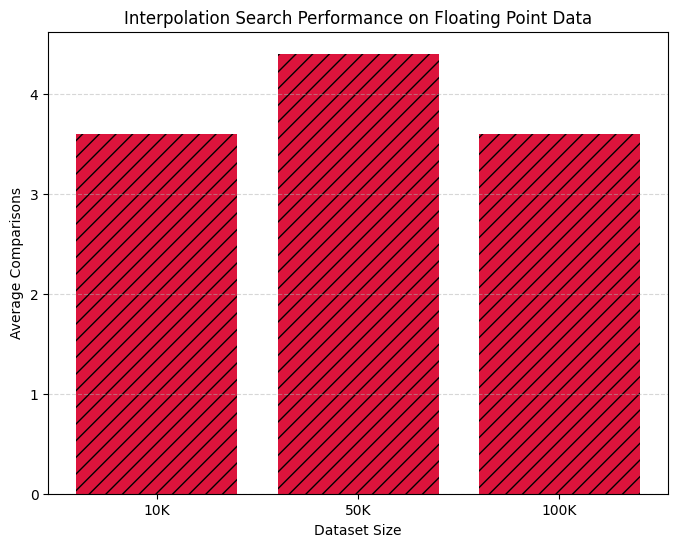

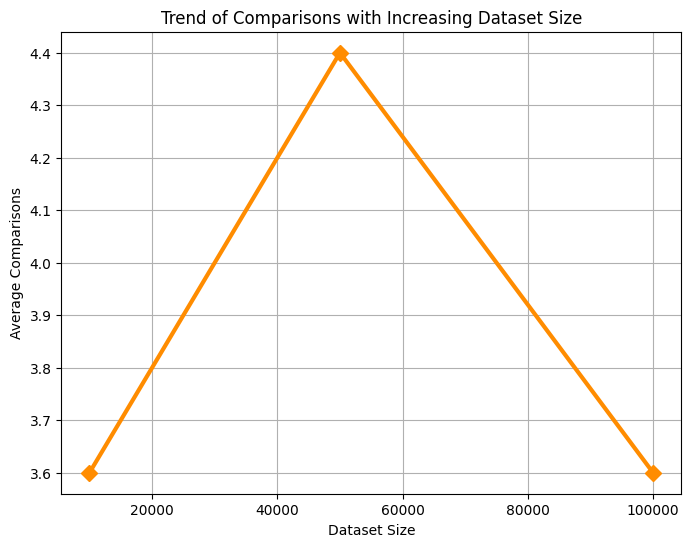

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------
# Interpolation Search for Floats
# ----------------------------------
def interpolation_search(arr, target):

    low = 0
    high = len(arr) - 1
    comparisons = 0

    while (low <= high and
           target >= arr[low] and
           target <= arr[high]):

        comparisons += 1

        if low == high:
            return comparisons

        pos = low + int(
            ((target - arr[low]) * (high - low))
            /
            (arr[high] - arr[low])
        )

        pos = max(low, min(pos, high))

        if abs(arr[pos] - target) < 0.0001:
            return comparisons

        elif arr[pos] < target:
            low = pos + 1

        else:
            high = pos - 1

    return comparisons


# ----------------------------------
# Dataset Sizes
# ----------------------------------
sizes = [10000, 50000, 100000]

average_comparisons = []

# ----------------------------------
# Analysis
# ----------------------------------
for size in sizes:

    # Generate sorted floating-point values
    data = np.sort(
        np.random.uniform(
            0.0,
            1000.0,
            size
        )
    )

    # Multiple search targets
    test_targets = [
        data[int(size * 0.10)],
        data[int(size * 0.30)],
        data[int(size * 0.50)],
        data[int(size * 0.70)],
        data[int(size * 0.90)]
    ]

    total_comparisons = 0

    for target in test_targets:
        total_comparisons += interpolation_search(
            data,
            target
        )

    average = total_comparisons / len(test_targets)

    average_comparisons.append(
        round(average, 2)
    )

# ----------------------------------
# Display Results
# ----------------------------------
print("\nINTERPOLATION SEARCH ON FLOATING-POINT DATA")
print("-" * 60)

for i in range(len(sizes)):
    print(
        f"Dataset Size = {sizes[i]}  -->  "
        f"Average Comparisons = {average_comparisons[i]}"
    )

# ----------------------------------
# BAR CHART
# ----------------------------------
labels = ["10K", "50K", "100K"]

plt.figure(figsize=(8, 6))

plt.bar(
    labels,
    average_comparisons,
    color='crimson',
    hatch='//'
)

plt.xlabel("Dataset Size")
plt.ylabel("Average Comparisons")
plt.title("Interpolation Search Performance on Floating Point Data")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# ----------------------------------
# LINE CHART
# ----------------------------------
plt.figure(figsize=(8, 6))

plt.plot(
    sizes,
    average_comparisons,
    marker='D',
    markersize=8,
    linewidth=3,
    color='darkorange'
)

plt.xlabel("Dataset Size")
plt.ylabel("Average Comparisons")
plt.title("Trend of Comparisons with Increasing Dataset Size")
plt.grid(True)

plt.show()